# Evaluation of Experiments

In [1]:
import os
import json

import numpy as np
import pylab as plt
import pandas as pd
import yaml

from tqdm.auto import tqdm
from pathlib import Path
from omegaconf import OmegaConf

In [13]:
model_names = ['resnet18', 'wideresnet282', 'wideresnet2810']
n_labeled = [str(x) for x in [50, 100, 250, 500, 1000]]
pretrain = ['False', 'True']
seeds = ['seed_1', 'seed_2', 'seed_3']

results = {mn:{t:{n_lab:{} for n_lab in n_labeled} for t in pretrain} for mn in model_names}
root_path = Path('/home/phahn/repositories/dal-toolbox/examples/self_supervised_learning/server_examples/server_results/finetuning/CIFAR10/')

count = 0

for mn in model_names:
    for n_lab in n_labeled:
        for t in pretrain:
            paths = sorted(list(root_path.glob(mn+"/"+t+"/"+n_lab+"/*")))
            for path in paths:
                if os.path.exists(path / 'results.json'):
                    count += 1
                    with open(path / 'results.json', 'r') as f:
                        run_results = json.load(f)
                    with open(path / '.hydra/config.yaml') as g:
                        conf = yaml.load(g, Loader=yaml.FullLoader)

                results[mn][t][n_lab][path.stem[-1]] = {'results': run_results, 'args': conf}
print(f"Number Runs: {count}/{len(model_names)*len(n_labeled)*len(pretrain)*len(seeds)}.")

Number Runs: 90/90.


In [15]:
test_accs = {mn:{t:{n_lab:[] for n_lab in n_labeled} for t in pretrain} for mn in model_names}
i = 0
for mn in model_names:
    for n_lab in n_labeled:
        for t in pretrain:
            for seed in range(1,4):
                seed = str(seed)
                i += 1
                test_accs[mn][t][n_lab].append(results[mn][t][n_lab][seed]['results']['test_accuracy'])

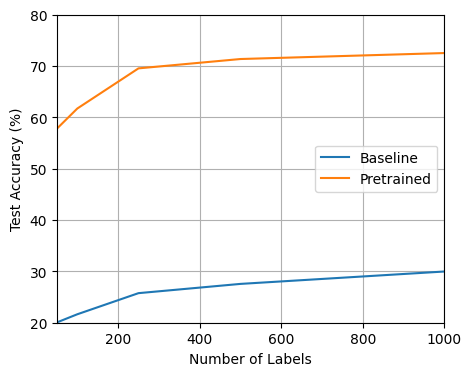

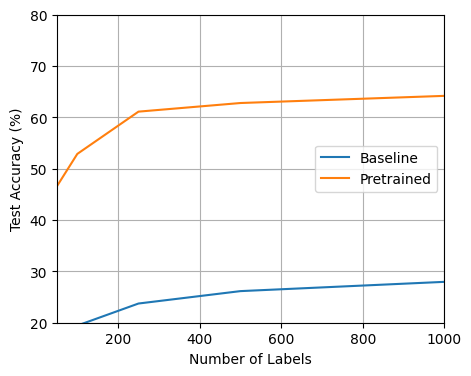

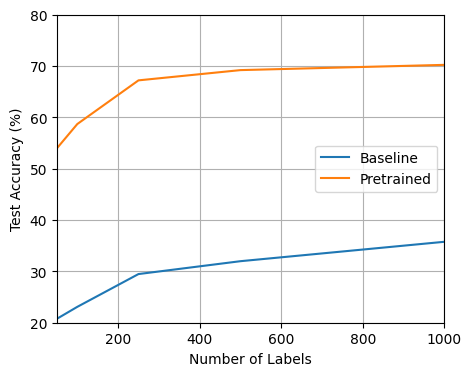

In [23]:
for mn in model_names:
    plt.figure(figsize=(5,4))
    plt.plot([int(n) for n in n_labeled], np.mean([test_accs[mn]['False'][n] for n in n_labeled], axis=1), label='Baseline')
    plt.plot([int(n) for n in n_labeled], np.mean([test_accs[mn]['True'][n] for n in n_labeled], axis=1), label='Pretrained')
    plt.grid(True)
    plt.xlabel('Number of Labels')
    plt.ylabel('Test Accuracy (%)')
    plt.xlim(int(n_labeled[0]), int(n_labeled[-1]))
    plt.ylim(20, 80)
    lgd = plt.legend(loc='center right')
    #plt.show()
    plt.savefig('./plots/'+mn+'.png', bbox_extra_artists=(lgd,), bbox_inches='tight')